In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetes (2).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Exploratory Data Analysis(EDA)

In [5]:
### Handle missing value

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
### Outlier capping

In [8]:
def outlier_capping(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    Lower_Extreme = Q1-1.5*IQR
    Upper_Extreme = Q3+1.5*IQR
    df[column] = df[column].apply(lambda x: Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for i in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,i)

<Axes: >

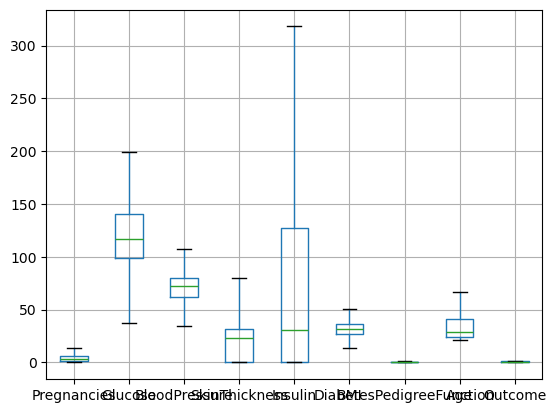

In [9]:
df.boxplot()

In [10]:
### Data Distribution of Historgram 

In [11]:
num_col = df.select_dtypes(include=['int','float']).columns
num_col

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

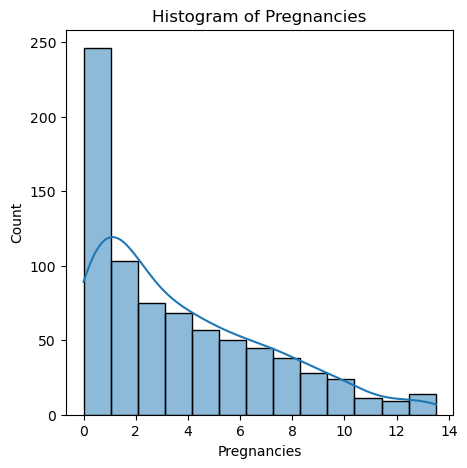

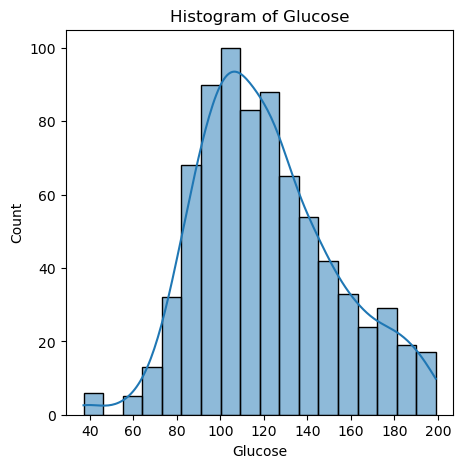

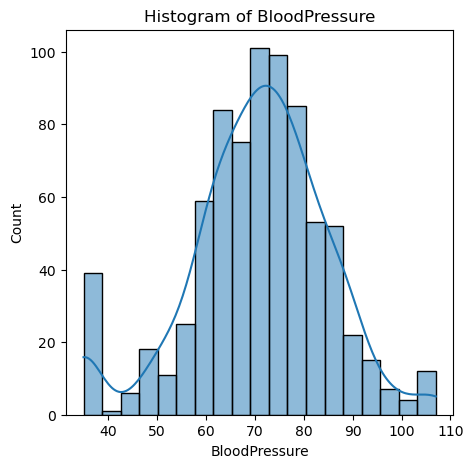

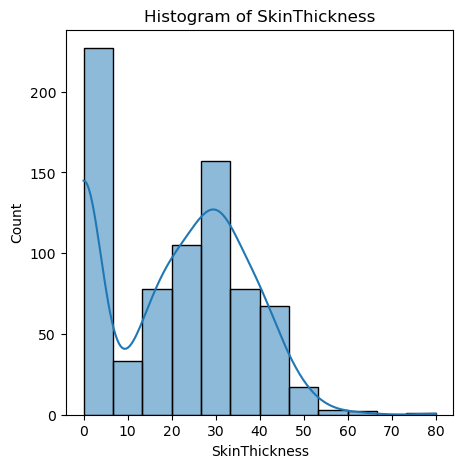

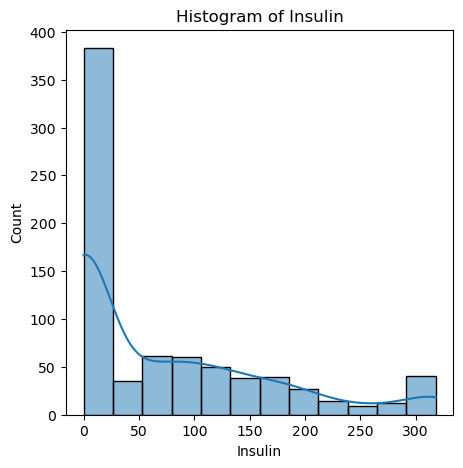

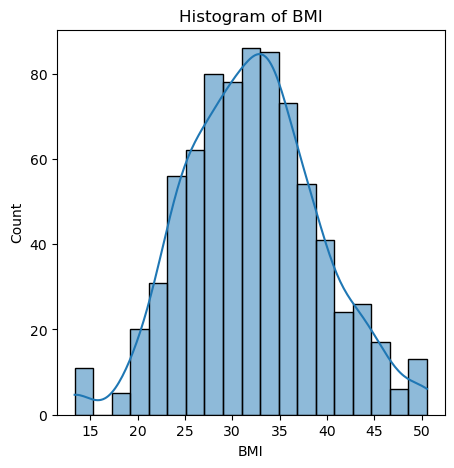

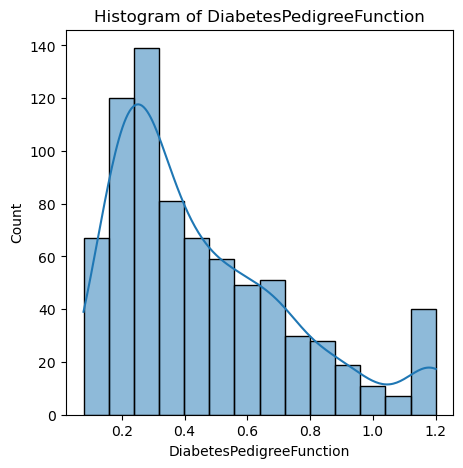

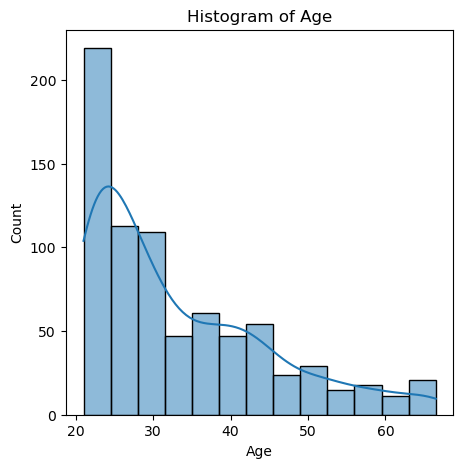

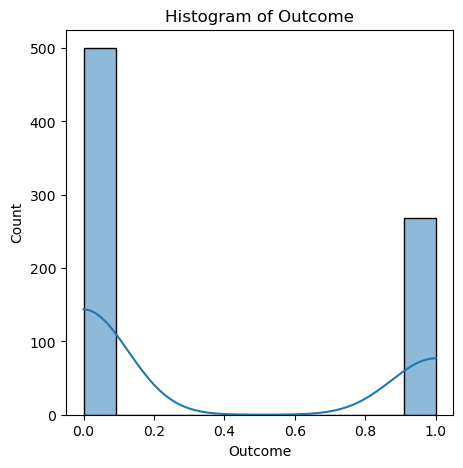

In [12]:
for i in num_col:
    plt.figure(figsize=(5,5))
    sns.histplot(x=df[i],kde = True)
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.title(f'Histogram of {i}')
    plt.show()

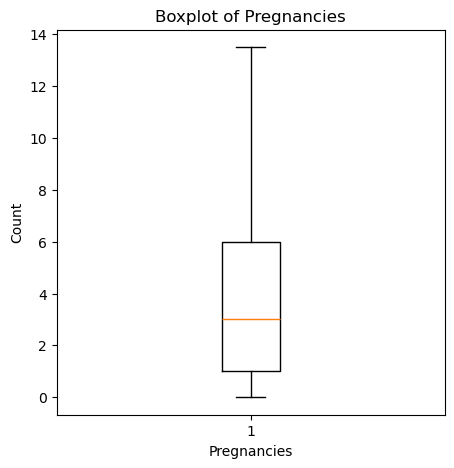

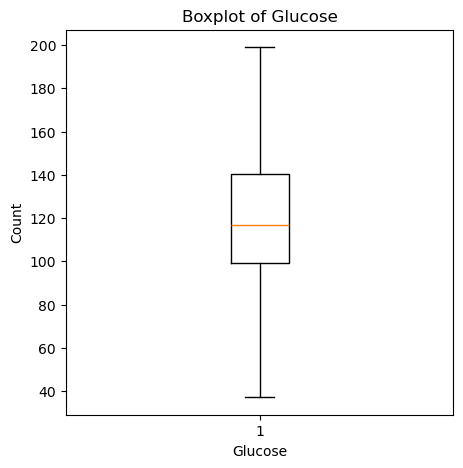

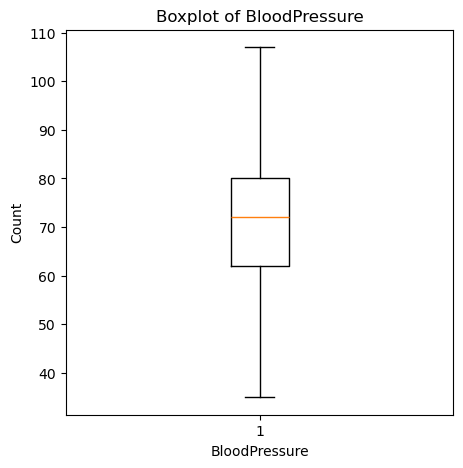

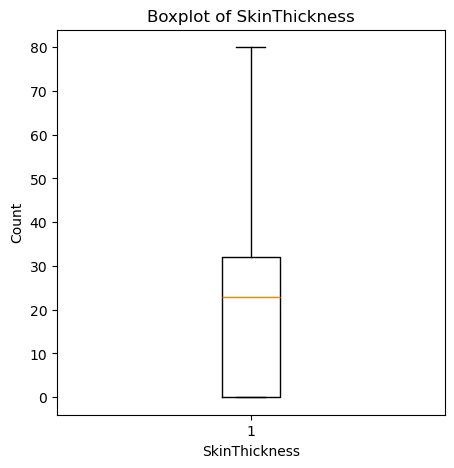

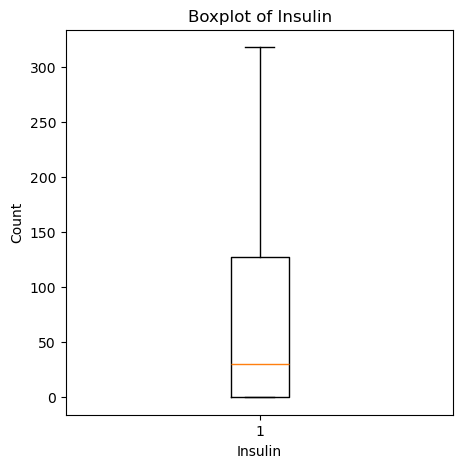

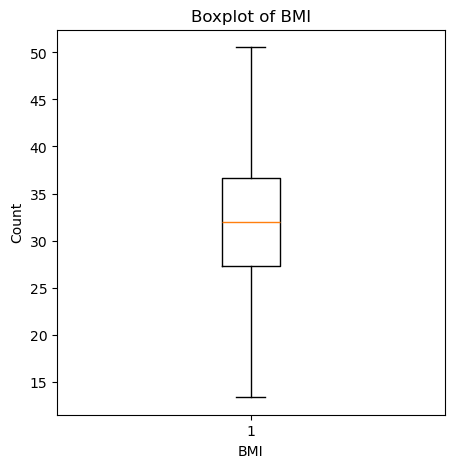

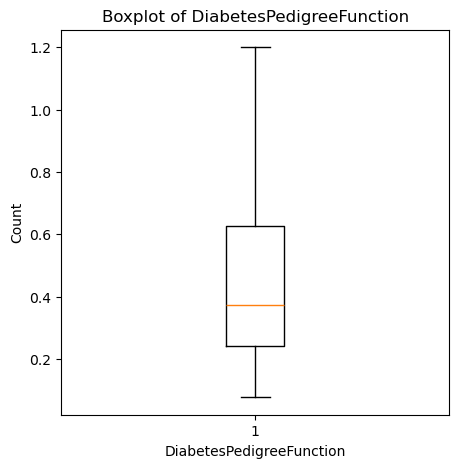

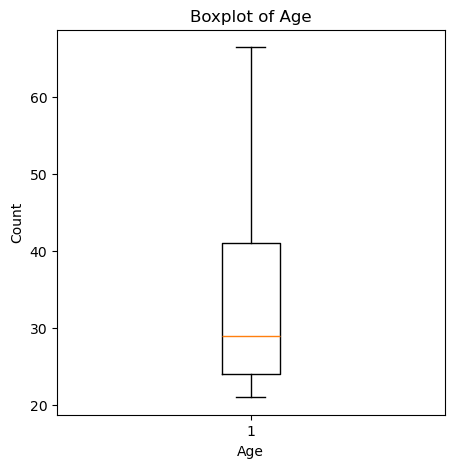

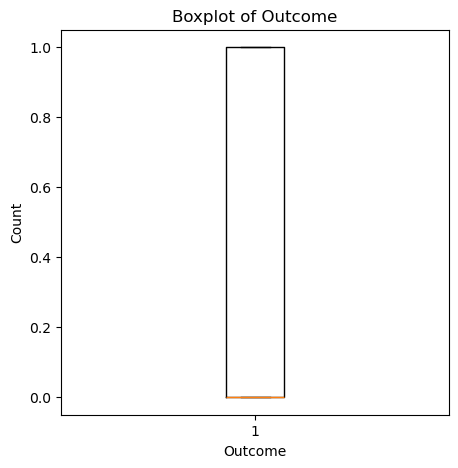

In [17]:
for i in num_col:
    plt.figure(figsize=(5,5))
    plt.boxplot(x=df[i])
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.title(f'Boxplot of {i}')
    plt.show()

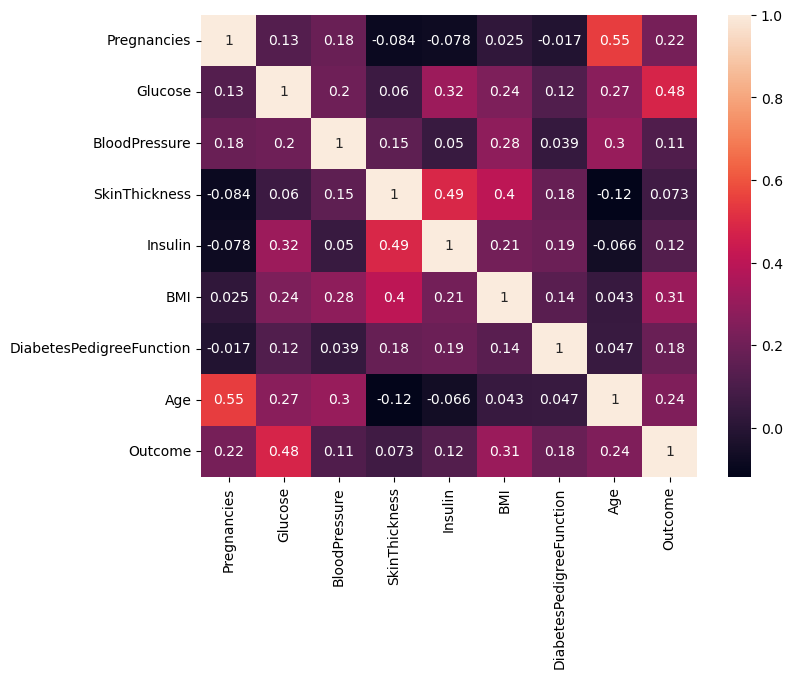

In [21]:
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(),annot = True)
plt.show()

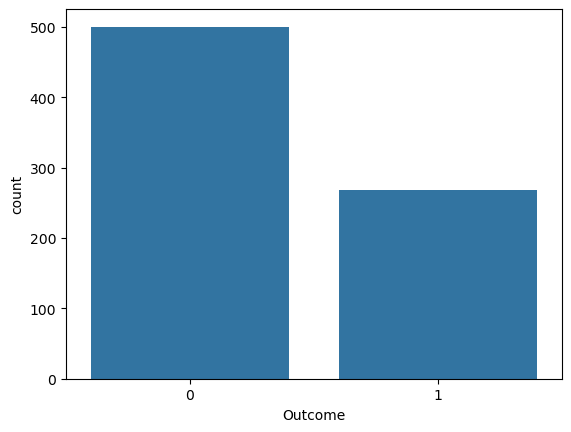

In [25]:
sns.countplot(x='Outcome',data=df)
plt.show()

In [28]:
feature = df.drop(columns=['Outcome'])
target = df['Outcome']

### Building Predictive Model

In [29]:
### Train and test 

In [32]:
from sklearn.model_selection import train_test_split,cross_validate,GridSearchCV

In [33]:
x_train,x_test,y_train,y_test = train_test_split(feature,target,train_size=0.75,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


In [34]:
### Model

In [59]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import accuracy_score,f1_score,precision_score,confusion_matrix,recall_score,classification_report
import warnings
warnings.filterwarnings('ignore')

In [60]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
y_pred1 = lgb_model.predict(x_test)
accuracy_score(y_test,y_pred1)

[LightGBM] [Info] Number of positive: 198, number of negative: 378
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 576, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.343750 -> initscore=-0.646627
[LightGBM] [Info] Start training from score -0.646627
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

0.6927083333333334

In [61]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(x_train,y_train)
y_pred2 = xgb_model.predict(x_test)
accuracy_score(y_test,y_pred2)

0.7395833333333334

In [67]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📊 {model_name} Performance:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))


In [68]:
evaluate_model(y_test, y_pred1, "LightGBM")


📊 LightGBM Performance:
Accuracy : 0.6927083333333334
Precision: 0.5873015873015873
Recall   : 0.5285714285714286
F1 Score : 0.556390977443609

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       122
           1       0.59      0.53      0.56        70

    accuracy                           0.69       192
   macro avg       0.67      0.66      0.66       192
weighted avg       0.69      0.69      0.69       192



In [64]:
evaluate_model(y_test, y_pred2, "XGBoost")


📊 XGBoost Performance:
Accuracy : 0.7395833333333334
Precision: 0.6666666666666666
Recall   : 0.5714285714285714
F1 Score : 0.6153846153846154

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       122
           1       0.67      0.57      0.62        70

    accuracy                           0.74       192
   macro avg       0.72      0.70      0.71       192
weighted avg       0.73      0.74      0.73       192



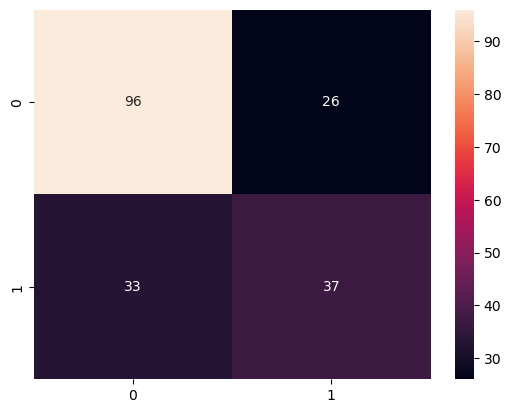

In [69]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

### Comparative Analysis

In [83]:
results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2)
    ],
    "Precision": [
        precision_score(y_test, y_pred1),
        precision_score(y_test, y_pred2)
    ],
    "Recall": [
        recall_score(y_test, y_pred1),
        recall_score(y_test, y_pred2)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2)
    ]
})

In [84]:
results

,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.692708,0.587302,0.528571,0.556391
1,XGBoost,0.739583,0.666667,0.571429,0.615385


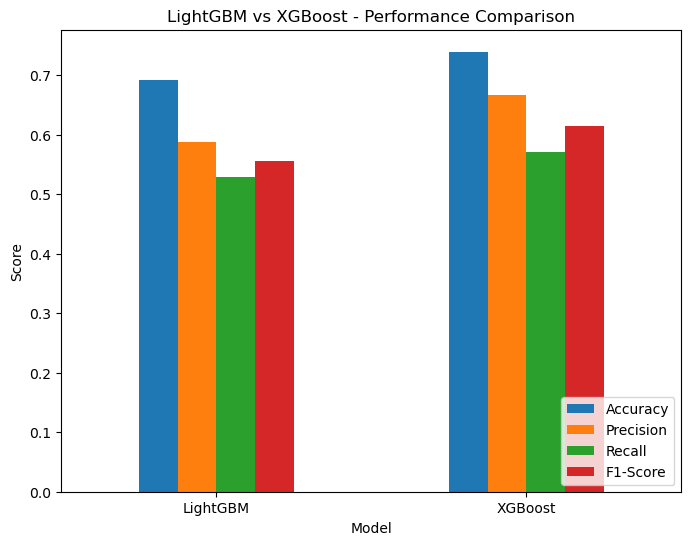

In [74]:
results.set_index("Model").plot(kind="bar", figsize=(8,6))
plt.title("LightGBM vs XGBoost - Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()